In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    /home/vishwesh/.cache/matplotlib/fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


In [2]:
df = pd.read_csv("../data/processed_data/bitcoin_final_with_embeddings_lag_7.csv")
df.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,bitcoin_news,summary_gpt-5-mini,summary_gpt-5-mini_lag1,...,Adj_Close_lag5,Adj_Close_lag6,Adj_Close_lag7,embedding_summary_gpt-5-mini_lag1,embedding_summary_gpt-5-mini_lag2,embedding_summary_gpt-5-mini_lag3,embedding_summary_gpt-5-mini_lag4,embedding_summary_gpt-5-mini_lag5,embedding_summary_gpt-5-mini_lag6,embedding_summary_gpt-5-mini_lag7
0,2018-01-01,14112.2,14112.2,13154.7,13657.2,13657.2,1.029120e+10,[{'title': 'Bitcoin vs gold: Safe haven battle...,"Since the beginning of the year, Bitcoin has s...",NaN,...,NaN,NaN,NaN,"[0.018885750323534012, 0.028458246961236, -0.0...","[0.018885750323534012, 0.028458246961236, -0.0...","[0.018885746598243713, 0.028458239510655403, -...","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
1,2018-01-02,13625.0,15444.6,13163.6,14982.1,14982.1,1.684660e+10,[{'title': 'Intel Leaks Details On Desktop Cor...,Intel's overclocking website listing leaked an...,"Since the beginning of the year, Bitcoin has s...",...,NaN,NaN,NaN,"[0.036350738257169724, -0.006545981392264366, ...","[0.018885750323534012, 0.028458246961236, -0.0...","[0.01888575218617916, 0.02845820225775242, -0....","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
2,2018-01-03,14978.2,15572.8,14844.5,15201.0,15201.0,1.687190e+10,[{'title': 'Forks in the Road: 2017 Bitcoin Fo...,"Bitcoin spot price was reported at $15,119 on ...",Intel's overclocking website listing leaked an...,...,NaN,NaN,NaN,"[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.01888575218617916, 0.02845820225775242, -0....","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
3,2018-01-04,15270.7,15739.7,14522.2,15599.2,15599.2,2.178320e+10,NaN,NaN,"Bitcoin spot price was reported at $15,119 on ...",...,NaN,NaN,NaN,"[-0.003045563353225589, 0.0033753064926713705,...","[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.01888575218617916, 0.02845820225775242, -0....","[0.018885742872953415, 0.02845822647213936, -0...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."
4,2018-01-05,15477.2,17705.2,15202.8,17429.5,17429.5,2.384090e+10,"[{'title': '6 AI techs that will rule 2018', '...","Bitcoin was described in one article as ""feroc...",NaN,...,NaN,NaN,NaN,"[0.018885746598243713, 0.028458239510655403, -...","[-0.003045563353225589, 0.0033753064926713705,...","[0.0006876131519675255, 0.0019628999289125204,...","[0.036350738257169724, -0.006545981392264366, ...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -...","[0.018885746598243713, 0.028458239510655403, -..."


In [3]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume',
       'bitcoin_news', 'summary_gpt-5-mini', 'summary_gpt-5-mini_lag1',
       'summary_gpt-5-mini_lag2', 'summary_gpt-5-mini_lag3',
       'summary_gpt-5-mini_lag4', 'summary_gpt-5-mini_lag5',
       'summary_gpt-5-mini_lag6', 'summary_gpt-5-mini_lag7', 'Open_lag1',
       'Open_lag2', 'Open_lag3', 'Open_lag4', 'Open_lag5', 'Open_lag6',
       'Open_lag7', 'High_lag1', 'High_lag2', 'High_lag3', 'High_lag4',
       'High_lag5', 'High_lag6', 'High_lag7', 'Low_lag1', 'Low_lag2',
       'Low_lag3', 'Low_lag4', 'Low_lag5', 'Low_lag6', 'Low_lag7',
       'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag4', 'Close_lag5',
       'Close_lag6', 'Close_lag7', 'Adj_Close_lag1', 'Adj_Close_lag2',
       'Adj_Close_lag3', 'Adj_Close_lag4', 'Adj_Close_lag5', 'Adj_Close_lag6',
       'Adj_Close_lag7', 'embedding_summary_gpt-5-mini_lag1',
       'embedding_summary_gpt-5-mini_lag2',
       'embedding_summary_gpt-5-mini_lag3',
    

In [4]:
dataset_lag = 7
emb_df = df[[f"embedding_summary_gpt-5-mini_lag{i}" for i in range(1, dataset_lag + 1)]]
emb_matrix = emb_df.applymap(lambda x: np.array(x[1:-1].split(",")).astype(float))

/tmp/ipykernel_594064/2740403591.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  emb_matrix = emb_df.applymap(lambda x: np.array(x[1:-1].split(",")).astype(float))


In [5]:
def get_scores(all_vectors, dir1):
    # all_vectors: N x D matrix of N vectors of dimension 4096
    # dir1: D-dimensional vector
    dots = all_vectors @ dir1
    dots_matrix = np.stack([dots, -dots], axis=1)
    exps = np.exp(dots_matrix)
    softmax_scores = exps / np.sum(exps, axis=1, keepdims=True)
    return softmax_scores

def create_lag_matrix(v, d):
    """
    v: Input vector of shape (N,) or (N, 1)
    d: Number of lags to create
    Returns: Matrix of shape (N, d)
    """
    v = v.ravel()
    N = v.shape[0]
    
    # Initialize matrix with NaNs
    lag_matrix = np.full((N, d), np.nan)
    
    for i in range(d):
        # The i-th lag shifts the data down by (i+1)
        lag_val = i + 1
        if lag_val < N:
            # Fill the column from index 'lag_val' to the end
            lag_matrix[lag_val:, i] = v[:-lag_val]
            
    return lag_matrix

null_vector = emb_matrix["embedding_summary_gpt-5-mini_lag1"][0]
rng = np.random.default_rng(seed=42)
r = rng.standard_normal(len(null_vector))
dir1 = r - (np.dot(r, null_vector) / np.dot(null_vector, null_vector)) * null_vector

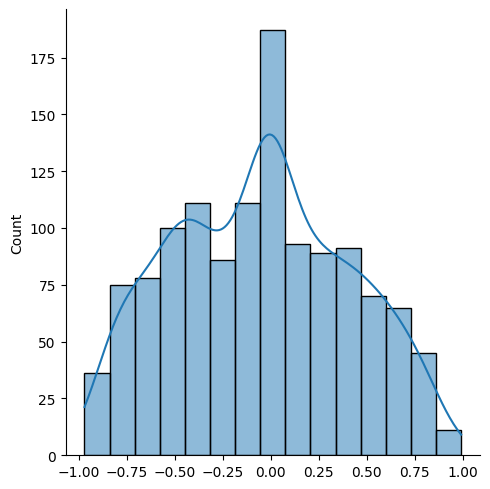

In [6]:
scale = 1
all_scores = get_scores(np.stack(emb_matrix["embedding_summary_gpt-5-mini_lag1"].values), dir1)
direction = scale * (all_scores[:, 0] - all_scores[:, 1])
sns.displot(direction,kde=True)

# #Generate lagged features
direction_lags = create_lag_matrix(direction, dataset_lag)
direction_lags[np.where(np.isnan(direction_lags))] = 0.0
direction_lags_df = pd.DataFrame(direction_lags, columns=[f"direction_lag{i}" for i in range(1, dataset_lag + 1)])
df = pd.concat([df, direction_lags_df], axis=1)

In [7]:
df_corr = df.copy()

target_lag = 3
input_cols = ["target", "text_signal"]
init_dict = {"target_lag1": 0.6, "target_lag2": 0.15, "target_lag3": 0.1}

In [8]:
# Create signal from text features
n_points = len(df)
target_mean = 6000
standard_deviation = 0  # Controls how "spread out" the noise is

text_signal = direction * np.random.normal(loc=target_mean, scale=standard_deviation, size=n_points) + 3000

#Generate target variable for additive model
text_signal_lags = create_lag_matrix(text_signal, dataset_lag)
text_signal_lags_df = pd.DataFrame(text_signal_lags, columns=[f"text_signal_lag{i}" for i in range(1, dataset_lag + 1)])
df_corr = pd.concat([df_corr, text_signal_lags_df], axis=1)

In [9]:
# trainable_cols_corr = [f"target_lag{j}" for j in range(1, target_lag + 1)]
trainable_cols_corr= [f"text_signal_lag{j}" for j in range(1, target_lag + 1)]

#generate synthetic target variable
noise = rng.standard_normal(len(df))
random_params = np.random.uniform(0, 1, size=target_lag)
random_params = random_params / np.linalg.norm(random_params) * 0.45
param_dict_corr = init_dict.copy()
param_dict_corr.update({f"text_signal_lag{i}": random_params[i-1] for i in range(1, target_lag + 1)})

## Target Generation with Correlation

/tmp/ipykernel_594064/2054296196.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_corr["target"].iloc[:target_lag] = additive_text_target
/tmp/ipykernel_594064/2054296196.py:8: SettingWithCopyWarning: 
A value is trying to be set on a 

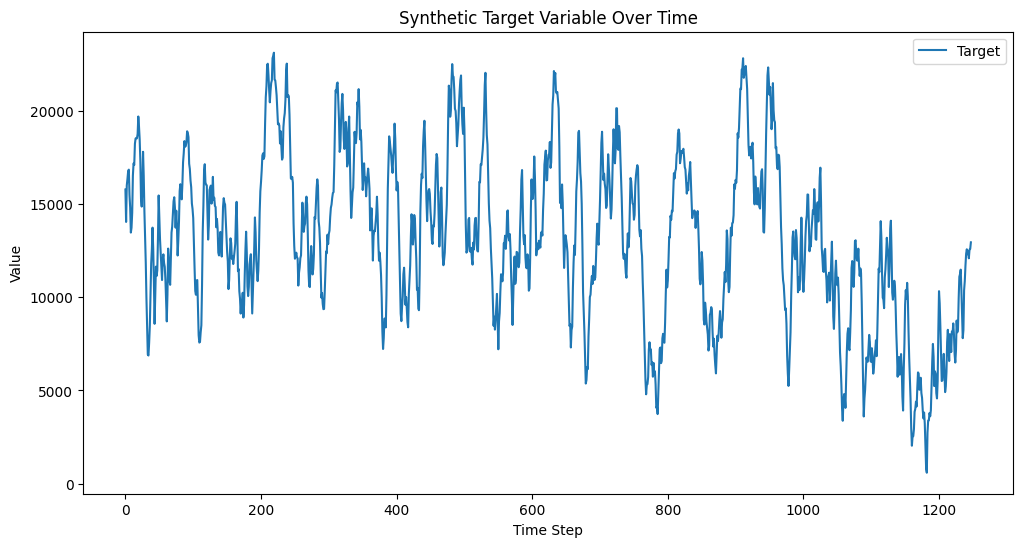

In [10]:
start_val = 13000
end_val = 17000
df_corr["target"] = np.nan

target = list(np.random.uniform(start_val, end_val, size=target_lag)) # Start with random values for the first 'target_lag' entries
additive_text_target = target.copy()

df_corr["target"].iloc[:target_lag] = additive_text_target

for i in range(target_lag, len(df_corr)):
    lagged_values_corr = [additive_text_target[i- j] for j in range(1, target_lag + 1)]
    
    feature_values_corr = df_corr.loc[i, trainable_cols_corr].values

    additive_text_target_value = sum(param_dict_corr[f"target_lag{j}"] * lagged_values_corr[j-1] for j in range(1, target_lag + 1))
    additive_text_target_value += sum(param_dict_corr[trainable_cols_corr[k]] * feature_values_corr[k] for k in range(len(trainable_cols_corr)))
    
    additive_text_target_value += noise[i] * 0 # Add some noise, for now no noise to keep it deterministic

    additive_text_target.append(additive_text_target_value)

df_corr["target"] = additive_text_target

#Plot the target variable and close price to visualize the synthetic data
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(df_corr)), df_corr["target"], label="Target")
# plt.plot(np.arange(len(df_corr)), df_corr["Adj_Close"], label="Adj Close Price")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("Synthetic Target Variable Over Time")
plt.legend()
plt.show()

In [11]:
#Save the synthetic dataset with lagged features and target variable
target_lagged_corr = create_lag_matrix(df_corr["target"].values, dataset_lag)
target_lags_df = pd.DataFrame(target_lagged_corr, columns=[f"target_lag{i}" for i in range(1, dataset_lag + 1)])
synthetic_df_corr = pd.concat([df_corr, target_lags_df], axis=1)
trainable_cols_corr.extend([f"target_lag{i}" for i in range(1, target_lag + 1)])
synthetic_df_corr.to_csv("../data/processed_data/bitcoin_synthetic_data_corr.csv", index=False)

### Baseline

In [12]:
# Train-test split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

clean_df = synthetic_df_corr.iloc[dataset_lag:]
clean_df_additive = synthetic_df_corr.iloc[dataset_lag:]
final_trainable_cols = trainable_cols_corr.copy()
final_trainable_cols_additive = trainable_cols_corr.copy()


train_size = 200
train_df = clean_df.iloc[:train_size]
test_df = clean_df.iloc[train_size:]

### Baseline
print("\nLinear Model: Additive terms from text direction with corr and lags")
linmod = LinearRegression()
linmod.fit(train_df[final_trainable_cols], train_df["target"])
y_train_pred = linmod.predict(train_df[final_trainable_cols])
y_test_pred = linmod.predict(test_df[final_trainable_cols])
print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
print("Train R2:", r2_score(train_df["target"], y_train_pred))
print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
print("Test R2:", r2_score(test_df["target"], y_test_pred))


print("\nLinear Model: Additive terms from text direction, no text signal used (to test if model is actually using text info)")
new_trainable_cols = [col for col in final_trainable_cols if 'text' not in col]
linmod_additive = LinearRegression()
linmod_additive.fit(train_df[new_trainable_cols], train_df["target"])
y_train_pred = linmod_additive.predict(train_df[new_trainable_cols])
y_test_pred = linmod_additive.predict(test_df[new_trainable_cols])
print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
print("Train R2:", r2_score(train_df["target"], y_train_pred))
print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
print("Test R2:", r2_score(test_df["target"], y_test_pred))


Linear Model: Additive terms from text direction with corr and lags
Train MAE: 1.5916157281026244e-12
Train R2: 1.0
Test MAE: 2.202313899610095e-12
Test R2: 1.0

Linear Model: Additive terms from text direction, no text signal used (to test if model is actually using text info)
Train MAE: 735.3188901845929
Train R2: 0.9036936937242864
Test MAE: 769.5980017380793
Test R2: 0.960558826433337


In [14]:
train_df_additive

,Date,Open,High,Low,Close,Adj_Close,Volume,bitcoin_news,summary_gpt-5-mini,summary_gpt-5-mini_lag1,...,text_signal_lag6,text_signal_lag7,target,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7
7,2018-01-08,16476.20,16537.90,14208.20,15170.10,15170.10,1.841390e+10,[{'title': 'Intel and AMD Join Forces on Tiny ...,Bitcoin's price history and recent moves: arti...,Vietnam's government has directed the State Ba...,...,15.811700,-1.332268e-12,26566.229856,28458.715774,27433.414220,25374.831967,21799.957740,13940.695191,14629.476688,14142.652055
8,2018-01-09,15123.70,15497.50,14424.00,14595.40,14595.40,1.666000e+10,[{'title': 'China on the verge of bursting bit...,A leaked January 2 document from China’s inter...,Bitcoin's price history and recent moves: arti...,...,2539.938112,1.581170e+01,26758.128101,26566.229856,28458.715774,27433.414220,25374.831967,21799.957740,13940.695191,14629.476688
9,2018-01-10,14588.50,14973.30,13691.20,14973.30,14973.30,1.850080e+10,"[{'title': ""End for Bitcoin? 'Three-quarters o...",A multi‑agency Chinese task force (including t...,A leaked January 2 document from China’s inter...,...,686.042169,2.539938e+03,24811.140920,26758.128101,26566.229856,28458.715774,27433.414220,25374.831967,21799.957740,13940.695191
10,2018-01-11,14968.20,15018.80,13105.90,13405.80,13405.80,1.653410e+10,"[{'title': 'Wait, It Turns Out KodakCoin Is No...",South Korea’s justice minister announced the g...,A multi‑agency Chinese task force (including t...,...,0.017736,6.860422e+02,26576.828191,24811.140920,26758.128101,26566.229856,28458.715774,27433.414220,25374.831967,21799.957740
11,2018-01-12,13453.90,14229.90,13158.10,13980.60,13980.60,1.206570e+10,NaN,NaN,South Korea’s justice minister announced the g...,...,-3253.071902,1.773600e-02,28097.861815,26576.828191,24811.140920,26758.128101,26566.229856,28458.715774,27433.414220,25374.831967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,2018-07-22,7417.80,7537.95,7383.82,7418.49,7418.49,3.695460e+09,NaN,NaN,NaN,...,1900.300483,1.736588e+03,16273.305040,15419.981287,16016.175621,16006.974317,13684.656513,10842.996671,8470.575471,9426.623360
203,2018-07-23,7414.71,7771.50,7409.10,7711.11,7711.11,5.132480e+09,"[{'title': ""Experts comment on what Bitcoin's ...",The articles state that Bitcoin’s computing po...,NaN,...,3700.785158,1.900300e+03,16671.542203,16273.305040,15419.981287,16016.175621,16006.974317,13684.656513,10842.996671,8470.575471
204,2018-07-24,7716.51,8424.27,7705.50,8424.27,8424.27,7.277690e+09,[{'title': 'Wasaga Beach pays cyber criminals ...,The Town of Wasaga Beach’s computer system was...,The articles state that Bitcoin’s computing po...,...,1322.784447,3.700785e+03,15360.688760,16671.542203,16273.305040,15419.981287,16016.175621,16006.974317,13684.656513,10842.996671
205,2018-07-25,8379.66,8416.87,8086.36,8181.39,8181.39,5.845400e+09,[{'title': 'Bitcoin (BTC): The Real Purpose of...,Bitcoin context and recent price/market-size f...,The Town of Wasaga Beach’s computer system was...,...,786.882292,1.322784e+03,14982.862346,15360.688760,16671.542203,16273.305040,15419.981287,16016.175621,16006.974317,13684.656513


In [15]:
final_trainable_cols_additive

['Open_lag1',
 'Open_lag2',
 'Open_lag3',
 'High_lag1',
 'High_lag2',
 'High_lag3',
 'Low_lag1',
 'Low_lag2',
 'Low_lag3',
 'Close_lag1',
 'Close_lag2',
 'Close_lag3',
 'Adj_Close_lag1',
 'Adj_Close_lag2',
 'Adj_Close_lag3',
 'text_signal_lag1',
 'text_signal_lag2',
 'text_signal_lag3',
 'target_lag1',
 'target_lag2',
 'target_lag3']

In [ ]:
# linmod_additive = LinearRegression()
# linmod_additive.fit(train_df_additive[final_trainable_cols_additive], train_df_additive["target"])
# y_train_pred = linmod_additive.predict(train_df_additive[final_trainable_cols_additive])
# y_test_pred = linmod_additive.predict(test_df_additive[final_trainable_cols_additive])

# print("Train MAE:", mean_absolute_error(train_df_additive["target"], y_train_pred))
# print("Train R2:", r2_score(train_df_additive["target"], y_train_pred))
# print("Test MAE:", mean_absolute_error(test_df_additive["target"], y_test_pred))
# print("Test R2:", r2_score(test_df_additive["target"], y_test_pred))

Train MAE: 9.19953890843317e-12
Train R2: 1.0
Test MAE: 4.0864903093384996e-11
Test R2: 1.0


In [ ]:
# import pandas as pd
# import numpy as np
# path = "../data/processed_data/bitcoin_synthetic_data_additive.csv"
# target_column = "target"
# target_lag = 3
# numeric_features = [f"Open_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"High_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Low_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Close_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"Adj_Close_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"text_signal_lag{i}" for i in range(1, target_lag + 1)] + \
#                    [f"target_lag{i}" for i in range(1, target_lag + 1)]
# synthetic_df = pd.read_csv(path).iloc[7:,:]
# synthetic_df[target_column] = np.log1p(np.abs(synthetic_df[target_column].values))
# synthetic_df[[col for col in numeric_features if "text_signal" not in col]] = np.log1p(np.abs(synthetic_df[[col for col in numeric_features if "text_signal" not in col]].values))
# synthetic_df[[col for col in numeric_features if "text_signal" in col]] = synthetic_df[[col for col in numeric_features if "text_signal"  in col]].values/6000

# # Train-test split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_absolute_error, r2_score

# train_size = 200
# train_df = synthetic_df.iloc[:train_size]
# test_df = synthetic_df.iloc[train_size:]

# linmod_additive = LinearRegression()
# linmod_additive.fit(train_df[numeric_features], train_df["target"])
# y_train_pred = linmod_additive.predict(train_df[numeric_features])
# y_test_pred = linmod_additive.predict(test_df[numeric_features])

# print("Train MAE:", mean_absolute_error(train_df["target"], y_train_pred))
# print("Train R2:", r2_score(train_df["target"], y_train_pred))
# print("Test MAE:", mean_absolute_error(test_df["target"], y_test_pred))
# print("Test R2:", r2_score(test_df["target"], y_test_pred))

Train MAE: 1.007265382213518e-11
Train R2: 1.0
Test MAE: 4.5041065124580575e-11
Test R2: 1.0
